# 🥇 Flagship Medallion Architecture <br> Case Study — 10 Messy Rows

## Bronze → Silver → Gold with DuckDB + Python

This notebook turns **10 messy sales records** into a complete, explainable medallion pipeline.

* The purpose is not dataset size. 
* The purpose is visibility: 
    * every row has a teaching role, 
    * every business rule is traceable, and 
    * every final Gold result can be explained from the original Bronze row.

By the end, students should understand:

- why Bronze preserves raw data
- why Silver applies business rules step-by-step
- why rejected rows are different from cancelled transactions
- why Gold should contain only trusted, analytics-ready data
- how a small star schema supports business reporting


## Business Rules

| Rule | Business rule | Pipeline action |
|---:|---|---|
| 1 | Missing `sale_id` | Treat as a **cancelled transaction** if the row is otherwise valid |
| 2 | Missing `product` | Reject the record |
| 3 | Missing or empty `customer_name` | Reject the record |
| 4 | Missing, null, or negative `discount` | Convert to `0.00` |
| 5 | Valid date formats only | Accept `MM/DD/YYYY` and `YYYY-MM-DD` |
| 6 | Missing, malformed, or invalid date | Reject the record |
| 7 | Exact duplicate rows | Keep first occurrence only |
| 8 | Final sale price | `final_sale_price = (quantity * unit_price) - discount` |

> Teaching point: the **order** of rules matters. We deduplicate before analytics, fix discounts before computing revenue, and parse dates before rejecting invalid date rows.


---
# Cell 1: Environment Setup

In [1]:
# =========================================================
# Cell 1: Environment Setup
# =========================================================
# This cell installs DuckDB only if it is missing.

import sys
import subprocess
import importlib.util

if importlib.util.find_spec("duckdb") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "duckdb"])

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:,.2f}".format)

print("DuckDB version:", duckdb.__version__)

DuckDB version: 1.5.2


---
# Cell 2: Create the 10-Row Source CSV

In [2]:
# =========================================================
# Cell 2: Create the 10-Row Source CSV
# =========================================================
# The notebook is self-contained. Running this cell creates the CSV.

DATA_DIR = Path("medallion_case_study_files")
DATA_DIR.mkdir(exist_ok=True)

csv_path = DATA_DIR / "sales_data_10_rows.csv"
db_path = DATA_DIR / "medallion_case_study.duckdb"

csv_text = """sale_id,sale_type,product,customer_name,customer_email,customer_country,quantity,unit_price,discount,store_location,sale_date
1001,ON-LINE,TV,John Smith,john@a.com,USA,1,900,50,USA,12/31/2025
1002,IN-STORE,IPHONE,Mary Jones,mary@a.com,CANADA,2,1100,-20,CANADA,2025-12-30
,ON-LINE,WATCH,Bob Lee,bob@a.com,USA,3,200,10,USA,12/29/2025
1004,ON-LINE,,Alice Brown,alice@a.com,ENGLAND,1,700,0,ENGLAND,12/28/2025
1005,IN-STORE,EBIKE,,no_name@a.com,USA,1,2200,100,USA,2025-12-27
1006,ON-LINE,COMPUTER,David Kim,david@a.com,USA,1,1500,,USA,31-12-25
1007,IN-STORE,IPAD,Susan Clark,susan@a.com,FRANCE,2,700,20,CANADA,
1001,ON-LINE,TV,John Smith,john@a.com,USA,1,900,50,USA,12/31/2025
1009,ON-LINE,WATCH,Rita Patel,rita@a.com,GERMANY,4,250,30,ENGLAND,2025-12-26
1010,IN-STORE,COMPUTER,Omar Khan,omar@a.com,MEXICO,1,1400,0,USA,2025-02-29
"""

csv_path.write_text(csv_text)
print(f"Created: {csv_path}")
print(f"Database: {db_path}")

Created: medallion_case_study_files/sales_data_10_rows.csv
Database: medallion_case_study_files/medallion_case_study.duckdb


---
# Cell 3: Connect to DuckDB and Define Helper Functions

In [3]:
# =========================================================
# Cell 3: Connect to DuckDB and Define Helper Functions
# =========================================================

con = duckdb.connect(str(db_path))

for schema in ["bronze", "silver", "gold"]:
    con.execute(f"DROP SCHEMA IF EXISTS {schema} CASCADE")

def run_sql(sql: str, title: str | None = None) -> pd.DataFrame:
    """Run SQL and display the result nicely."""
    if title:
        display(Markdown(f"### {title}"))
    df = con.execute(sql).df()
    display(df)
    return df

def exec_sql(sql: str, message: str) -> None:
    """Execute SQL and print a compact success message."""
    con.execute(sql)
    print(message)

# 🟫 Bronze Layer

## Goal

* Bronze is the raw landing area. 
* In Bronze, we **do not clean the data yet**. 
* We preserve the source as-is so every Silver and Gold decision can be traced back to the original record.

We add one technical column:

- `row_id`: a stable row number for lineage, debugging, and classroom discussion.


In [4]:
# =========================================================
# Cell 4: Bronze - Load Raw CSV Exactly as Landed
# =========================================================

exec_sql(f"""
CREATE SCHEMA IF NOT EXISTS bronze;

CREATE OR REPLACE TABLE bronze.sales_raw AS
SELECT
    ROW_NUMBER() OVER () AS row_id,
    *
FROM read_csv_auto(
    '{csv_path.as_posix()}',
    header = true,
    all_varchar = true
);
""", "Created bronze.sales_raw")

bronze_df = run_sql("""
SELECT *
FROM bronze.sales_raw
ORDER BY row_id;
""", "Bronze: raw landed data")


Created bronze.sales_raw


### Bronze: raw landed data

,row_id,sale_id,sale_type,product,customer_name,customer_email,customer_country,quantity,unit_price,discount,store_location,sale_date
0,1,1001,ON-LINE,TV,John Smith,john@a.com,USA,1,900,50,USA,12/31/2025
1,2,1002,IN-STORE,IPHONE,Mary Jones,mary@a.com,CANADA,2,1100,-20,CANADA,2025-12-30
2,3,None,ON-LINE,WATCH,Bob Lee,bob@a.com,USA,3,200,10,USA,12/29/2025
3,4,1004,ON-LINE,None,Alice Brown,alice@a.com,ENGLAND,1,700,0,ENGLAND,12/28/2025
4,5,1005,IN-STORE,EBIKE,None,no_name@a.com,USA,1,2200,100,USA,2025-12-27
5,6,1006,ON-LINE,COMPUTER,David Kim,david@a.com,USA,1,1500,None,USA,31-12-25
6,7,1007,IN-STORE,IPAD,Susan Clark,susan@a.com,FRANCE,2,700,20,CANADA,None
7,8,1001,ON-LINE,TV,John Smith,john@a.com,USA,1,900,50,USA,12/31/2025
8,9,1009,ON-LINE,WATCH,Rita Patel,rita@a.com,GERMANY,4,250,30,ENGLAND,2025-12-26
9,10,1010,IN-STORE,COMPUTER,Omar Khan,omar@a.com,MEXICO,1,1400,0,USA,2025-02-29


---
# Cell 5: Bronze Snapshot

In [5]:
# =========================================================
# Cell 5: Bronze Snapshot
# =========================================================

run_sql("""
SELECT 'bronze.sales_raw' AS stage, COUNT(*) AS row_count
FROM bronze.sales_raw;
""", "Bronze row count")

### Bronze row count

,stage,row_count
0,bronze.sales_raw,10


,stage,row_count
0,bronze.sales_raw,10


# ⚪ Silver Layer

* Silver is where we apply data-quality rules and make the data trustworthy. 
* We will build Silver in small steps, so students can inspect the exact effect of each rule.


## Silver Step 1 — Deduplicate Exact Duplicate Rows

Rows 1 and 8 are exact duplicates in the source file. We ignore `row_id` when detecting duplicates because `row_id` is only a technical lineage column.


In [6]:
# =========================================================
# Cell 6: Silver Step 1 - Deduplicate Exact Duplicate Rows
# =========================================================

exec_sql("""
CREATE SCHEMA IF NOT EXISTS silver;

CREATE OR REPLACE TABLE silver.step01_dedup AS
SELECT * EXCLUDE (rn)
FROM (
    SELECT *,
           ROW_NUMBER() OVER (
               PARTITION BY
                   sale_id, sale_type, product, customer_name,
                   customer_email, customer_country, quantity,
                   unit_price, discount, store_location, sale_date
               ORDER BY row_id
           ) AS rn
    FROM bronze.sales_raw
)
WHERE rn = 1;
""", "Created silver.step01_dedup")

run_sql("""
SELECT *
FROM silver.step01_dedup
ORDER BY row_id;
""", "After deduplication")


Created silver.step01_dedup


### After deduplication

,row_id,sale_id,sale_type,product,customer_name,customer_email,customer_country,quantity,unit_price,discount,store_location,sale_date
0,1,1001,ON-LINE,TV,John Smith,john@a.com,USA,1,900,50,USA,12/31/2025
1,2,1002,IN-STORE,IPHONE,Mary Jones,mary@a.com,CANADA,2,1100,-20,CANADA,2025-12-30
2,3,None,ON-LINE,WATCH,Bob Lee,bob@a.com,USA,3,200,10,USA,12/29/2025
3,4,1004,ON-LINE,None,Alice Brown,alice@a.com,ENGLAND,1,700,0,ENGLAND,12/28/2025
4,5,1005,IN-STORE,EBIKE,None,no_name@a.com,USA,1,2200,100,USA,2025-12-27
5,6,1006,ON-LINE,COMPUTER,David Kim,david@a.com,USA,1,1500,None,USA,31-12-25
6,7,1007,IN-STORE,IPAD,Susan Clark,susan@a.com,FRANCE,2,700,20,CANADA,None
7,9,1009,ON-LINE,WATCH,Rita Patel,rita@a.com,GERMANY,4,250,30,ENGLAND,2025-12-26
8,10,1010,IN-STORE,COMPUTER,Omar Khan,omar@a.com,MEXICO,1,1400,0,USA,2025-02-29


,row_id,sale_id,sale_type,product,customer_name,customer_email,customer_country,quantity,unit_price,discount,store_location,sale_date
0,1,1001,ON-LINE,TV,John Smith,john@a.com,USA,1,900,50,USA,12/31/2025
1,2,1002,IN-STORE,IPHONE,Mary Jones,mary@a.com,CANADA,2,1100,-20,CANADA,2025-12-30
2,3,None,ON-LINE,WATCH,Bob Lee,bob@a.com,USA,3,200,10,USA,12/29/2025
3,4,1004,ON-LINE,None,Alice Brown,alice@a.com,ENGLAND,1,700,0,ENGLAND,12/28/2025
4,5,1005,IN-STORE,EBIKE,None,no_name@a.com,USA,1,2200,100,USA,2025-12-27
5,6,1006,ON-LINE,COMPUTER,David Kim,david@a.com,USA,1,1500,None,USA,31-12-25
6,7,1007,IN-STORE,IPAD,Susan Clark,susan@a.com,FRANCE,2,700,20,CANADA,None
7,9,1009,ON-LINE,WATCH,Rita Patel,rita@a.com,GERMANY,4,250,30,ENGLAND,2025-12-26
8,10,1010,IN-STORE,COMPUTER,Omar Khan,omar@a.com,MEXICO,1,1400,0,USA,2025-02-29


---
# Cell 7: Rows Removed by Deduplication

In [7]:
# =========================================================
# Cell 7: Rows Removed by Deduplication
# =========================================================

run_sql("""
WITH marked AS (
    SELECT *,
           ROW_NUMBER() OVER (
               PARTITION BY
                   sale_id, sale_type, product, customer_name,
                   customer_email, customer_country, quantity,
                   unit_price, discount, store_location, sale_date
               ORDER BY row_id
           ) AS duplicate_rank
    FROM bronze.sales_raw
)
SELECT
    row_id, sale_id, product, customer_name, sale_date,
    'DUPLICATE_OF_EARLIER_ROW' AS removal_reason
FROM marked
WHERE duplicate_rank > 1
ORDER BY row_id;
""", "Rows removed by deduplication")

### Rows removed by deduplication

,row_id,sale_id,product,customer_name,sale_date,removal_reason
0,8,1001,TV,John Smith,12/31/2025,DUPLICATE_OF_EARLIER_ROW


,row_id,sale_id,product,customer_name,sale_date,removal_reason
0,8,1001,TV,John Smith,12/31/2025,DUPLICATE_OF_EARLIER_ROW


## Silver Step 2 — Standardize Strings and Prepare Fields

Before applying business rules, we normalize text and safely convert numeric fields. We also preserve raw values such as `sale_id_raw`, `discount_raw`, and `sale_date_raw` for auditability.


In [8]:
# =========================================================
# Cell 8: Silver Step 2 - Standardize Strings and Prepare Fields
# =========================================================

exec_sql("""
CREATE OR REPLACE TABLE silver.step02_standardized AS
SELECT
    row_id,
    NULLIF(TRIM(sale_id), '') AS sale_id_raw,
    UPPER(NULLIF(TRIM(sale_type), '')) AS sale_type,
    UPPER(NULLIF(TRIM(product), '')) AS product,
    NULLIF(TRIM(customer_name), '') AS customer_name,
    LOWER(NULLIF(TRIM(customer_email), '')) AS customer_email,
    UPPER(NULLIF(TRIM(customer_country), '')) AS customer_country,
    TRY_CAST(NULLIF(TRIM(quantity), '') AS INTEGER) AS quantity,
    TRY_CAST(NULLIF(TRIM(unit_price), '') AS DOUBLE) AS unit_price,
    NULLIF(TRIM(discount), '') AS discount_raw,
    UPPER(NULLIF(TRIM(store_location), '')) AS store_location,
    NULLIF(TRIM(sale_date), '') AS sale_date_raw
FROM silver.step01_dedup;
""", "Created silver.step02_standardized")

run_sql("""
SELECT *
FROM silver.step02_standardized
ORDER BY row_id;
""", "After standardization")


Created silver.step02_standardized


### After standardization

,row_id,sale_id_raw,sale_type,product,customer_name,customer_email,customer_country,quantity,unit_price,discount_raw,store_location,sale_date_raw
0,1,1001,ON-LINE,TV,John Smith,john@a.com,USA,1,900.00,50,USA,12/31/2025
1,2,1002,IN-STORE,IPHONE,Mary Jones,mary@a.com,CANADA,2,"1,100.00",-20,CANADA,2025-12-30
2,3,None,ON-LINE,WATCH,Bob Lee,bob@a.com,USA,3,200.00,10,USA,12/29/2025
3,4,1004,ON-LINE,None,Alice Brown,alice@a.com,ENGLAND,1,700.00,0,ENGLAND,12/28/2025
4,5,1005,IN-STORE,EBIKE,None,no_name@a.com,USA,1,"2,200.00",100,USA,2025-12-27
5,6,1006,ON-LINE,COMPUTER,David Kim,david@a.com,USA,1,"1,500.00",None,USA,31-12-25
6,7,1007,IN-STORE,IPAD,Susan Clark,susan@a.com,FRANCE,2,700.00,20,CANADA,None
7,9,1009,ON-LINE,WATCH,Rita Patel,rita@a.com,GERMANY,4,250.00,30,ENGLAND,2025-12-26
8,10,1010,IN-STORE,COMPUTER,Omar Khan,omar@a.com,MEXICO,1,"1,400.00",0,USA,2025-02-29


,row_id,sale_id_raw,sale_type,product,customer_name,customer_email,customer_country,quantity,unit_price,discount_raw,store_location,sale_date_raw
0,1,1001,ON-LINE,TV,John Smith,john@a.com,USA,1,900.00,50,USA,12/31/2025
1,2,1002,IN-STORE,IPHONE,Mary Jones,mary@a.com,CANADA,2,"1,100.00",-20,CANADA,2025-12-30
2,3,None,ON-LINE,WATCH,Bob Lee,bob@a.com,USA,3,200.00,10,USA,12/29/2025
3,4,1004,ON-LINE,None,Alice Brown,alice@a.com,ENGLAND,1,700.00,0,ENGLAND,12/28/2025
4,5,1005,IN-STORE,EBIKE,None,no_name@a.com,USA,1,"2,200.00",100,USA,2025-12-27
5,6,1006,ON-LINE,COMPUTER,David Kim,david@a.com,USA,1,"1,500.00",None,USA,31-12-25
6,7,1007,IN-STORE,IPAD,Susan Clark,susan@a.com,FRANCE,2,700.00,20,CANADA,None
7,9,1009,ON-LINE,WATCH,Rita Patel,rita@a.com,GERMANY,4,250.00,30,ENGLAND,2025-12-26
8,10,1010,IN-STORE,COMPUTER,Omar Khan,omar@a.com,MEXICO,1,"1,400.00",0,USA,2025-02-29


## Silver Step 3 — Fix Discount Values

Business rule: missing, null, or negative discounts become `0.00`.

Affected rows:

- row 2: discount is `-20`, so it becomes `0`
- row 6: discount is missing, so it becomes `0`


In [9]:
# =========================================================
# Cell 9: Silver Step 3 - Fix Discount Values
# =========================================================

exec_sql("""
CREATE OR REPLACE TABLE silver.step03_discount_fixed AS
SELECT
    *,
    CASE
        WHEN discount_num IS NULL THEN 0.00
        WHEN discount_num < 0 THEN 0.00
        ELSE discount_num
    END AS discount
FROM (
    SELECT *, TRY_CAST(discount_raw AS DOUBLE) AS discount_num
    FROM silver.step02_standardized
);
""", "Created silver.step03_discount_fixed")

run_sql("""
SELECT row_id, discount_raw, discount_num, discount
FROM silver.step03_discount_fixed
ORDER BY row_id;
""", "Discount before and after")


Created silver.step03_discount_fixed


### Discount before and after

,row_id,discount_raw,discount_num,discount
0,1,50,50.00,50.00
1,2,-20,-20.00,0.00
2,3,10,10.00,10.00
3,4,0,0.00,0.00
4,5,100,100.00,100.00
5,6,None,NaN,0.00
6,7,20,20.00,20.00
7,9,30,30.00,30.00
8,10,0,0.00,0.00


,row_id,discount_raw,discount_num,discount
0,1,50,50.00,50.00
1,2,-20,-20.00,0.00
2,3,10,10.00,10.00
3,4,0,0.00,0.00
4,5,100,100.00,100.00
5,6,None,NaN,0.00
6,7,20,20.00,20.00
7,9,30,30.00,30.00
8,10,0,0.00,0.00


## Silver Step 4 — Parse Sale Dates

Only two formats are accepted:

- `MM/DD/YYYY`
- `YYYY-MM-DD`

A date can still fail even when the format looks correct. For example, `2025-02-29` has the right pattern, but 2025 is not a leap year.


In [10]:
# =========================================================
# Cell 10: Silver Step 4 - Parse Sale Dates
# =========================================================

exec_sql("""
CREATE OR REPLACE TABLE silver.step04_date_parsed AS
SELECT
    *,
    CASE
        WHEN sale_date_raw LIKE '__/__/____' THEN
            TRY_STRPTIME(sale_date_raw, '%m/%d/%Y')::DATE
        WHEN sale_date_raw LIKE '____-__-__' THEN
            TRY_STRPTIME(sale_date_raw, '%Y-%m-%d')::DATE
        ELSE NULL
    END AS sale_date
FROM silver.step03_discount_fixed;
""", "Created silver.step04_date_parsed")

run_sql("""
SELECT row_id, sale_date_raw, sale_date
FROM silver.step04_date_parsed
ORDER BY row_id;
""", "Date parsing before and after")


Created silver.step04_date_parsed


### Date parsing before and after

,row_id,sale_date_raw,sale_date
0,1,12/31/2025,2025-12-31
1,2,2025-12-30,2025-12-30
2,3,12/29/2025,2025-12-29
3,4,12/28/2025,2025-12-28
4,5,2025-12-27,2025-12-27
5,6,31-12-25,NaT
6,7,None,NaT
7,9,2025-12-26,2025-12-26
8,10,2025-02-29,NaT


,row_id,sale_date_raw,sale_date
0,1,12/31/2025,2025-12-31
1,2,2025-12-30,2025-12-30
2,3,12/29/2025,2025-12-29
3,4,12/28/2025,2025-12-28
4,5,2025-12-27,2025-12-27
5,6,31-12-25,NaT
6,7,None,NaT
7,9,2025-12-26,2025-12-26
8,10,2025-02-29,NaT


---
# Cell 11: Date Parsing Debug View

In [11]:
# =========================================================
# Cell 11: Date Parsing Debug View
# =========================================================

run_sql("""
SELECT
    row_id,
    sale_date_raw,
    sale_date,
    CASE
        WHEN sale_date_raw IS NULL THEN 'MISSING_DATE'
        WHEN sale_date_raw NOT LIKE '__/__/____'
         AND sale_date_raw NOT LIKE '____-__-__' THEN 'INVALID_FORMAT'
        WHEN sale_date IS NULL THEN 'INVALID_CALENDAR_DATE'
        ELSE 'VALID_DATE'
    END AS date_quality_status
FROM silver.step04_date_parsed
ORDER BY row_id;
""", "Date quality status")

### Date quality status

,row_id,sale_date_raw,sale_date,date_quality_status
0,1,12/31/2025,2025-12-31,VALID_DATE
1,2,2025-12-30,2025-12-30,VALID_DATE
2,3,12/29/2025,2025-12-29,VALID_DATE
3,4,12/28/2025,2025-12-28,VALID_DATE
4,5,2025-12-27,2025-12-27,VALID_DATE
5,6,31-12-25,NaT,INVALID_FORMAT
6,7,None,NaT,MISSING_DATE
7,9,2025-12-26,2025-12-26,VALID_DATE
8,10,2025-02-29,NaT,INVALID_CALENDAR_DATE


,row_id,sale_date_raw,sale_date,date_quality_status
0,1,12/31/2025,2025-12-31,VALID_DATE
1,2,2025-12-30,2025-12-30,VALID_DATE
2,3,12/29/2025,2025-12-29,VALID_DATE
3,4,12/28/2025,2025-12-28,VALID_DATE
4,5,2025-12-27,2025-12-27,VALID_DATE
5,6,31-12-25,NaT,INVALID_FORMAT
6,7,None,NaT,MISSING_DATE
7,9,2025-12-26,2025-12-26,VALID_DATE
8,10,2025-02-29,NaT,INVALID_CALENDAR_DATE


## Silver Step 5 — Reject Invalid Rows

Rejected rows are records that cannot be trusted for analytics because required business fields are missing or invalid.

Rejected rows are **not** the same as cancelled transactions.


In [12]:
# =========================================================
# Cell 12: Silver Step 5 - Build Rejected Records Table
# =========================================================

exec_sql("""
CREATE OR REPLACE TABLE silver.rejected_records AS
SELECT
    *,
    CASE
        WHEN product IS NULL THEN 'REJECT_MISSING_PRODUCT'
        WHEN customer_name IS NULL THEN 'REJECT_MISSING_CUSTOMER_NAME'
        WHEN customer_email IS NULL THEN 'REJECT_MISSING_EMAIL'
        WHEN POSITION('@' IN customer_email) = 0 THEN 'REJECT_INVALID_EMAIL'
        WHEN quantity IS NULL OR quantity <= 0 THEN 'REJECT_INVALID_QUANTITY'
        WHEN unit_price IS NULL OR unit_price <= 0 THEN 'REJECT_INVALID_UNIT_PRICE'
        WHEN store_location IS NULL THEN 'REJECT_MISSING_STORE_LOCATION'
        WHEN sale_date IS NULL THEN 'REJECT_INVALID_OR_MISSING_SALE_DATE'
        ELSE 'REJECT_OTHER'
    END AS reject_reason
FROM silver.step04_date_parsed
WHERE
    product IS NULL
    OR customer_name IS NULL
    OR customer_email IS NULL
    OR POSITION('@' IN customer_email) = 0
    OR quantity IS NULL OR quantity <= 0
    OR unit_price IS NULL OR unit_price <= 0
    OR store_location IS NULL
    OR sale_date IS NULL;
""", "Created silver.rejected_records")

run_sql("""
SELECT row_id, sale_id_raw, product, customer_name, sale_date_raw, sale_date, reject_reason
FROM silver.rejected_records
ORDER BY row_id;
""", "Rejected records")


Created silver.rejected_records


### Rejected records

,row_id,sale_id_raw,product,customer_name,sale_date_raw,sale_date,reject_reason
0,4,1004,None,Alice Brown,12/28/2025,2025-12-28,REJECT_MISSING_PRODUCT
1,5,1005,EBIKE,None,2025-12-27,2025-12-27,REJECT_MISSING_CUSTOMER_NAME
2,6,1006,COMPUTER,David Kim,31-12-25,NaT,REJECT_INVALID_OR_MISSING_SALE_DATE
3,7,1007,IPAD,Susan Clark,None,NaT,REJECT_INVALID_OR_MISSING_SALE_DATE
4,10,1010,COMPUTER,Omar Khan,2025-02-29,NaT,REJECT_INVALID_OR_MISSING_SALE_DATE


,row_id,sale_id_raw,product,customer_name,sale_date_raw,sale_date,reject_reason
0,4,1004,None,Alice Brown,12/28/2025,2025-12-28,REJECT_MISSING_PRODUCT
1,5,1005,EBIKE,None,2025-12-27,2025-12-27,REJECT_MISSING_CUSTOMER_NAME
2,6,1006,COMPUTER,David Kim,31-12-25,NaT,REJECT_INVALID_OR_MISSING_SALE_DATE
3,7,1007,IPAD,Susan Clark,None,NaT,REJECT_INVALID_OR_MISSING_SALE_DATE
4,10,1010,COMPUTER,Omar Khan,2025-02-29,NaT,REJECT_INVALID_OR_MISSING_SALE_DATE


## Silver Step 6 — Capture Cancelled Transactions

Business rule: missing `sale_id` means a cancelled transaction **only if the row is otherwise valid**.

This distinction is important:

- row 3 is cancelled because it has no `sale_id`, but all other important fields are valid
- rows with missing product, missing customer name, or invalid dates are rejected, not cancelled


In [13]:
# =========================================================
# Cell 13: Silver Step 6 - Build Cancelled Transactions Table
# =========================================================

exec_sql("""
CREATE OR REPLACE TABLE silver.cancelled_transactions AS
SELECT *
FROM silver.step04_date_parsed
WHERE
    sale_id_raw IS NULL
    AND product IS NOT NULL
    AND customer_name IS NOT NULL
    AND customer_email IS NOT NULL
    AND POSITION('@' IN customer_email) > 0
    AND quantity IS NOT NULL AND quantity > 0
    AND unit_price IS NOT NULL AND unit_price > 0
    AND store_location IS NOT NULL
    AND sale_date IS NOT NULL;
""", "Created silver.cancelled_transactions")

run_sql("""
SELECT row_id, sale_id_raw, product, customer_name, quantity, unit_price, discount, sale_date
FROM silver.cancelled_transactions
ORDER BY row_id;
""", "Cancelled transactions")


Created silver.cancelled_transactions


### Cancelled transactions

,row_id,sale_id_raw,product,customer_name,quantity,unit_price,discount,sale_date
0,3,None,WATCH,Bob Lee,3,200.00,10.00,2025-12-29


,row_id,sale_id_raw,product,customer_name,quantity,unit_price,discount,sale_date
0,3,None,WATCH,Bob Lee,3,200.00,10.00,2025-12-29


## Silver Step 7 — Build Trusted Clean Sales

Now we create the trusted sales table.

This table includes only rows that are not duplicates, not rejected, not cancelled, and have all required fields valid.

```text
final_sale_price = (quantity * unit_price) - discount
```


In [14]:
# =========================================================
# Cell 14: Silver Step 7 - Build Trusted Clean Sales
# =========================================================

exec_sql("""
CREATE OR REPLACE TABLE silver.sales_clean AS
SELECT
    TRY_CAST(sale_id_raw AS INTEGER) AS sale_id,
    sale_type,
    product,
    customer_name,
    customer_email,
    customer_country,
    store_location,
    sale_date,
    quantity,
    unit_price,
    discount,
    (quantity * unit_price) - discount AS final_sale_price
FROM silver.step04_date_parsed
WHERE
    TRY_CAST(sale_id_raw AS INTEGER) IS NOT NULL
    AND product IS NOT NULL
    AND customer_name IS NOT NULL
    AND customer_email IS NOT NULL
    AND POSITION('@' IN customer_email) > 0
    AND quantity IS NOT NULL AND quantity > 0
    AND unit_price IS NOT NULL AND unit_price > 0
    AND store_location IS NOT NULL
    AND sale_date IS NOT NULL;
""", "Created silver.sales_clean")

run_sql("""
SELECT *
FROM silver.sales_clean
ORDER BY sale_id;
""", "Trusted Silver sales")


Created silver.sales_clean


### Trusted Silver sales

,sale_id,sale_type,product,customer_name,customer_email,customer_country,store_location,sale_date,quantity,unit_price,discount,final_sale_price
0,1001,ON-LINE,TV,John Smith,john@a.com,USA,USA,2025-12-31,1,900.00,50.00,850.00
1,1002,IN-STORE,IPHONE,Mary Jones,mary@a.com,CANADA,CANADA,2025-12-30,2,"1,100.00",0.00,"2,200.00"
2,1009,ON-LINE,WATCH,Rita Patel,rita@a.com,GERMANY,ENGLAND,2025-12-26,4,250.00,30.00,970.00


,sale_id,sale_type,product,customer_name,customer_email,customer_country,store_location,sale_date,quantity,unit_price,discount,final_sale_price
0,1001,ON-LINE,TV,John Smith,john@a.com,USA,USA,2025-12-31,1,900.00,50.00,850.00
1,1002,IN-STORE,IPHONE,Mary Jones,mary@a.com,CANADA,CANADA,2025-12-30,2,"1,100.00",0.00,"2,200.00"
2,1009,ON-LINE,WATCH,Rita Patel,rita@a.com,GERMANY,ENGLAND,2025-12-26,4,250.00,30.00,970.00


# 📉 Pipeline Audit and Teaching Funnel

A medallion pipeline should be explainable. The next cells summarize exactly what happened to the 10 original rows.


In [15]:
# =========================================================
# Cell 15: End-to-End Funnel
# =========================================================

funnel_df = run_sql("""
SELECT '01 Bronze raw rows' AS stage, COUNT(*) AS row_count FROM bronze.sales_raw
UNION ALL
SELECT '02 After deduplication', COUNT(*) FROM silver.step01_dedup
UNION ALL
SELECT '03 Rejected records', COUNT(*) FROM silver.rejected_records
UNION ALL
SELECT '04 Cancelled transactions', COUNT(*) FROM silver.cancelled_transactions
UNION ALL
SELECT '05 Trusted clean sales', COUNT(*) FROM silver.sales_clean;
""", "End-to-end funnel")


### End-to-end funnel

,stage,row_count
0,01 Bronze raw rows,10
1,02 After deduplication,9
2,03 Rejected records,5
3,04 Cancelled transactions,1
4,05 Trusted clean sales,3


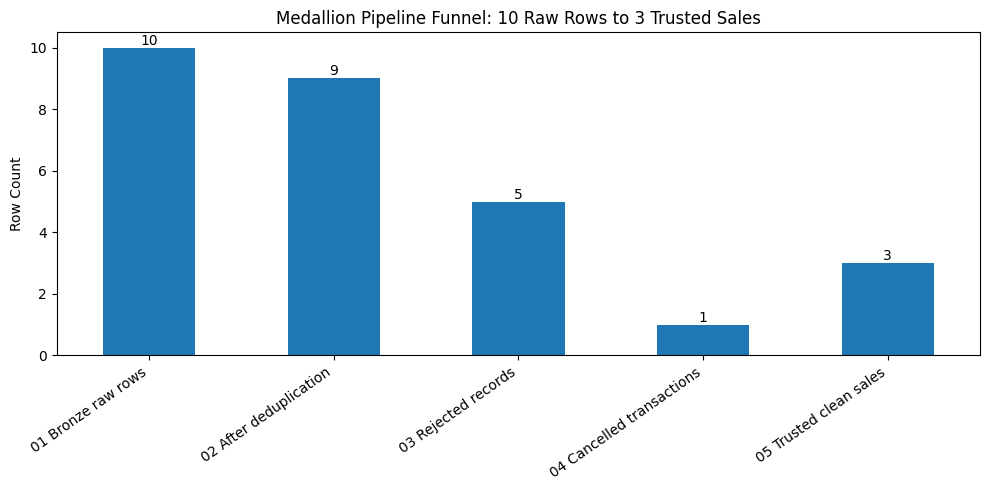

In [16]:
# =========================================================
# Cell 16: Funnel Plot
# =========================================================

ax = funnel_df.plot(kind="bar", x="stage", y="row_count", legend=False, figsize=(10, 5))
ax.set_title("Medallion Pipeline Funnel: 10 Raw Rows to 3 Trusted Sales")
ax.set_xlabel("")
ax.set_ylabel("Row Count")
ax.bar_label(ax.containers[0])
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


In [17]:
# =========================================================
# Cell 17: Row-Level Outcome Map
# =========================================================
# This table is one of the best teaching artifacts in the notebook.

row_outcome_df = run_sql("""
WITH duplicate_rows AS (
    SELECT row_id
    FROM (
        SELECT *,
               ROW_NUMBER() OVER (
                   PARTITION BY
                       sale_id, sale_type, product, customer_name,
                       customer_email, customer_country, quantity,
                       unit_price, discount, store_location, sale_date
                   ORDER BY row_id
               ) AS duplicate_rank
        FROM bronze.sales_raw
    )
    WHERE duplicate_rank > 1
),
rejected AS (
    SELECT row_id, reject_reason FROM silver.rejected_records
),
cancelled AS (
    SELECT row_id FROM silver.cancelled_transactions
),
trusted AS (
    SELECT s4.row_id
    FROM silver.step04_date_parsed s4
    JOIN silver.sales_clean sc
      ON TRY_CAST(s4.sale_id_raw AS INTEGER) = sc.sale_id
)
SELECT
    b.row_id,
    b.sale_id,
    b.product,
    b.customer_name,
    b.sale_date,
    CASE
        WHEN d.row_id IS NOT NULL THEN 'REMOVED_DUPLICATE'
        WHEN r.row_id IS NOT NULL THEN r.reject_reason
        WHEN c.row_id IS NOT NULL THEN 'CANCELLED_TRANSACTION'
        WHEN t.row_id IS NOT NULL THEN 'TRUSTED_SALE'
        ELSE 'CHECK_NEEDED'
    END AS final_outcome
FROM bronze.sales_raw b
LEFT JOIN duplicate_rows d ON b.row_id = d.row_id
LEFT JOIN rejected r ON b.row_id = r.row_id
LEFT JOIN cancelled c ON b.row_id = c.row_id
LEFT JOIN trusted t ON b.row_id = t.row_id
ORDER BY b.row_id;
""", "Row-level outcome map")


### Row-level outcome map

,row_id,sale_id,product,customer_name,sale_date,final_outcome
0,1,1001,TV,John Smith,12/31/2025,TRUSTED_SALE
1,2,1002,IPHONE,Mary Jones,2025-12-30,TRUSTED_SALE
2,3,None,WATCH,Bob Lee,12/29/2025,CANCELLED_TRANSACTION
3,4,1004,None,Alice Brown,12/28/2025,REJECT_MISSING_PRODUCT
4,5,1005,EBIKE,None,2025-12-27,REJECT_MISSING_CUSTOMER_NAME
5,6,1006,COMPUTER,David Kim,31-12-25,REJECT_INVALID_OR_MISSING_SALE_DATE
6,7,1007,IPAD,Susan Clark,None,REJECT_INVALID_OR_MISSING_SALE_DATE
7,8,1001,TV,John Smith,12/31/2025,REMOVED_DUPLICATE
8,9,1009,WATCH,Rita Patel,2025-12-26,TRUSTED_SALE
9,10,1010,COMPUTER,Omar Khan,2025-02-29,REJECT_INVALID_OR_MISSING_SALE_DATE


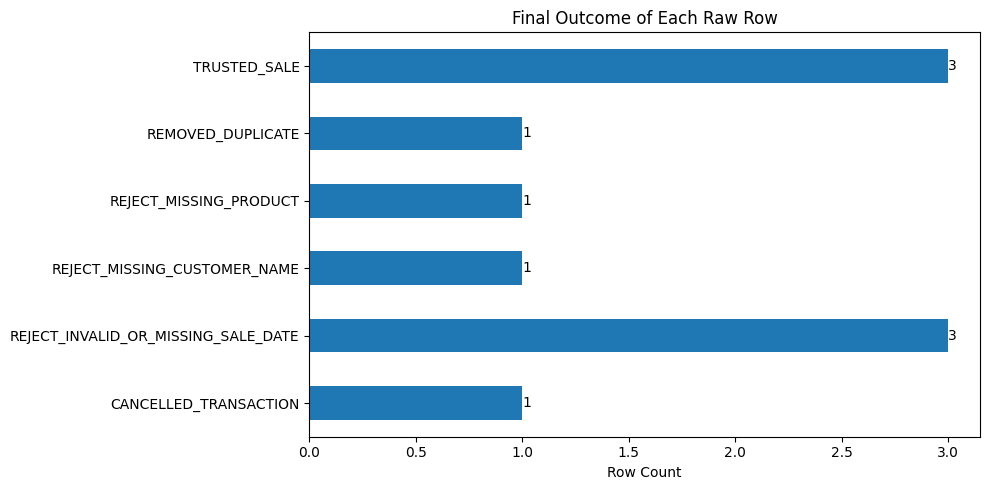

In [18]:
# =========================================================
# Cell 18: Outcome Plot
# =========================================================

outcome_counts = row_outcome_df.groupby("final_outcome", as_index=False).size().rename(columns={"size": "row_count"})

ax = outcome_counts.plot(kind="barh", x="final_outcome", y="row_count", legend=False, figsize=(10, 5))
ax.set_title("Final Outcome of Each Raw Row")
ax.set_xlabel("Row Count")
ax.set_ylabel("")
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()


# 🟡 Gold Layer

* Gold is the analytics layer. 
* Gold should not include rejected rows or cancelled transactions
* Gold should be built from trusted Silver data only.

We will build a small star schema:

```text
             dim_customer
                   │
                   │
dim_product ─── fact_sales ─── dim_date
```


---
# Cell 19: Gold - Build Dimension Tables

In [19]:
# =========================================================
# Cell 19: Gold - Build Dimension Tables
# =========================================================

exec_sql("""
CREATE SCHEMA IF NOT EXISTS gold;

CREATE OR REPLACE TABLE gold.dim_customer AS
SELECT
    ROW_NUMBER() OVER (ORDER BY customer_email) AS customer_key,
    customer_name,
    customer_email,
    customer_country
FROM (
    SELECT DISTINCT customer_name, customer_email, customer_country
    FROM silver.sales_clean
);

CREATE OR REPLACE TABLE gold.dim_product AS
SELECT
    ROW_NUMBER() OVER (ORDER BY product) AS product_key,
    product
FROM (
    SELECT DISTINCT product
    FROM silver.sales_clean
);

CREATE OR REPLACE TABLE gold.dim_date AS
SELECT
    ROW_NUMBER() OVER (ORDER BY sale_date) AS date_key,
    sale_date AS full_date,
    EXTRACT(YEAR FROM sale_date) AS year_num,
    EXTRACT(MONTH FROM sale_date) AS month_num,
    EXTRACT(DAY FROM sale_date) AS day_num,
    STRFTIME(sale_date, '%Y-%m') AS year_month,
    STRFTIME(sale_date, '%B') AS month_name,
    STRFTIME(sale_date, '%A') AS day_name,
    CASE
        WHEN STRFTIME(sale_date, '%w') IN ('0','6') THEN 'WEEKEND'
        ELSE 'WEEKDAY'
    END AS day_type
FROM (
    SELECT DISTINCT sale_date
    FROM silver.sales_clean
);
""", "Created Gold dimension tables")

run_sql("SELECT * FROM gold.dim_customer ORDER BY customer_key;", "gold.dim_customer")
run_sql("SELECT * FROM gold.dim_product ORDER BY product_key;", "gold.dim_product")
run_sql("SELECT * FROM gold.dim_date ORDER BY date_key;", "gold.dim_date")

Created Gold dimension tables


### gold.dim_customer

,customer_key,customer_name,customer_email,customer_country
0,1,John Smith,john@a.com,USA
1,2,Mary Jones,mary@a.com,CANADA
2,3,Rita Patel,rita@a.com,GERMANY


### gold.dim_product

,product_key,product
0,1,IPHONE
1,2,TV
2,3,WATCH


### gold.dim_date

,date_key,full_date,year_num,month_num,day_num,year_month,month_name,day_name,day_type
0,1,2025-12-26,2025,12,26,2025-12,December,Friday,WEEKDAY
1,2,2025-12-30,2025,12,30,2025-12,December,Tuesday,WEEKDAY
2,3,2025-12-31,2025,12,31,2025-12,December,Wednesday,WEEKDAY


,date_key,full_date,year_num,month_num,day_num,year_month,month_name,day_name,day_type
0,1,2025-12-26,2025,12,26,2025-12,December,Friday,WEEKDAY
1,2,2025-12-30,2025,12,30,2025-12,December,Tuesday,WEEKDAY
2,3,2025-12-31,2025,12,31,2025-12,December,Wednesday,WEEKDAY


---
# Cell 20: Gold - Build Fact Table

In [20]:
# =========================================================
# Cell 20: Gold - Build Fact Table
# =========================================================

exec_sql("""
CREATE OR REPLACE TABLE gold.fact_sales AS
SELECT
    s.sale_id,
    c.customer_key,
    p.product_key,
    d.date_key,
    s.quantity,
    s.unit_price,
    s.discount,
    s.final_sale_price
FROM silver.sales_clean s
JOIN gold.dim_customer c
    ON s.customer_email = c.customer_email
JOIN gold.dim_product p
    ON s.product = p.product
JOIN gold.dim_date d
    ON s.sale_date = d.full_date;
""", "Created gold.fact_sales")

run_sql("""
SELECT *
FROM gold.fact_sales
ORDER BY sale_id;
""", "gold.fact_sales")

Created gold.fact_sales


### gold.fact_sales

,sale_id,customer_key,product_key,date_key,quantity,unit_price,discount,final_sale_price
0,1001,1,2,3,1,900.00,50.00,850.00
1,1002,2,1,2,2,"1,100.00",0.00,"2,200.00"
2,1009,3,3,1,4,250.00,30.00,970.00


,sale_id,customer_key,product_key,date_key,quantity,unit_price,discount,final_sale_price
0,1001,1,2,3,1,900.00,50.00,850.00
1,1002,2,1,2,2,"1,100.00",0.00,"2,200.00"
2,1009,3,3,1,4,250.00,30.00,970.00


In [21]:
# =========================================================
# Cell 21: Gold - Business-Friendly Star Schema Query
# =========================================================

star_df = run_sql("""
SELECT
    f.sale_id,
    d.full_date,
    d.day_name,
    c.customer_name,
    c.customer_country,
    p.product,
    f.quantity,
    f.unit_price,
    f.discount,
    f.final_sale_price
FROM gold.fact_sales f
JOIN gold.dim_customer c ON f.customer_key = c.customer_key
JOIN gold.dim_product p ON f.product_key = p.product_key
JOIN gold.dim_date d ON f.date_key = d.date_key
ORDER BY d.full_date;
""", "Gold star-schema result: trusted business view")


### Gold star-schema result: trusted business view

,sale_id,full_date,day_name,customer_name,customer_country,product,quantity,unit_price,discount,final_sale_price
0,1009,2025-12-26,Friday,Rita Patel,GERMANY,WATCH,4,250.00,30.00,970.00
1,1002,2025-12-30,Tuesday,Mary Jones,CANADA,IPHONE,2,"1,100.00",0.00,"2,200.00"
2,1001,2025-12-31,Wednesday,John Smith,USA,TV,1,900.00,50.00,850.00


# 📊 Gold Analytics Examples

* These examples are intentionally small because the dataset has only 3 trusted transactions. 
* The teaching point is that business questions should use Gold, not raw Bronze.


### Revenue by product

,product,total_revenue
0,IPHONE,"2,200.00"
1,WATCH,970.00
2,TV,850.00


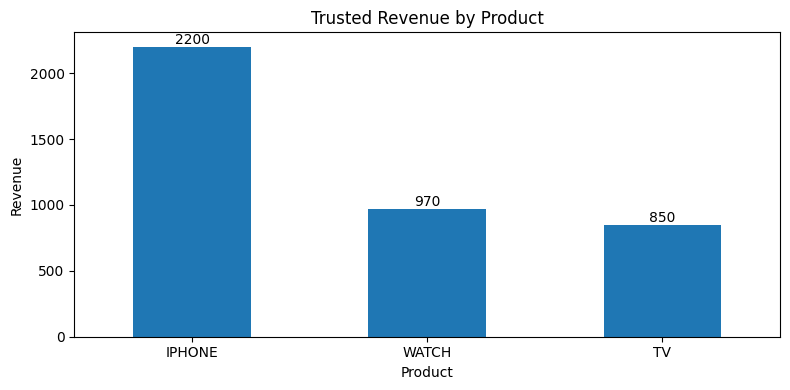

In [22]:
# =========================================================
# Cell 22: Analytics Query 1 - Revenue by Product
# =========================================================

revenue_by_product = run_sql("""
SELECT
    p.product,
    SUM(f.final_sale_price) AS total_revenue
FROM gold.fact_sales f
JOIN gold.dim_product p ON f.product_key = p.product_key
GROUP BY p.product
ORDER BY total_revenue DESC;
""", "Revenue by product")

ax = revenue_by_product.plot(kind="bar", x="product", y="total_revenue", legend=False, figsize=(8, 4))
ax.set_title("Trusted Revenue by Product")
ax.set_xlabel("Product")
ax.set_ylabel("Revenue")
ax.bar_label(ax.containers[0], fmt="%.0f")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Revenue by customer country

,customer_country,total_revenue
0,CANADA,"2,200.00"
1,GERMANY,970.00
2,USA,850.00


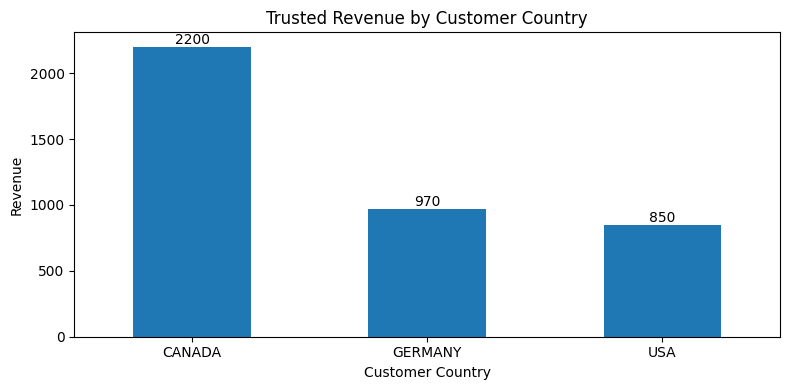

In [23]:
# =========================================================
# Cell 23: Analytics Query 2 - Revenue by Customer Country
# =========================================================

revenue_by_country = run_sql("""
SELECT
    c.customer_country,
    SUM(f.final_sale_price) AS total_revenue
FROM gold.fact_sales f
JOIN gold.dim_customer c ON f.customer_key = c.customer_key
GROUP BY c.customer_country
ORDER BY total_revenue DESC;
""", "Revenue by customer country")

ax = revenue_by_country.plot(kind="bar", x="customer_country", y="total_revenue", legend=False, figsize=(8, 4))
ax.set_title("Trusted Revenue by Customer Country")
ax.set_xlabel("Customer Country")
ax.set_ylabel("Revenue")
ax.bar_label(ax.containers[0], fmt="%.0f")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Daily trusted sales trend

,full_date,daily_revenue
0,2025-12-26,970.00
1,2025-12-30,"2,200.00"
2,2025-12-31,850.00


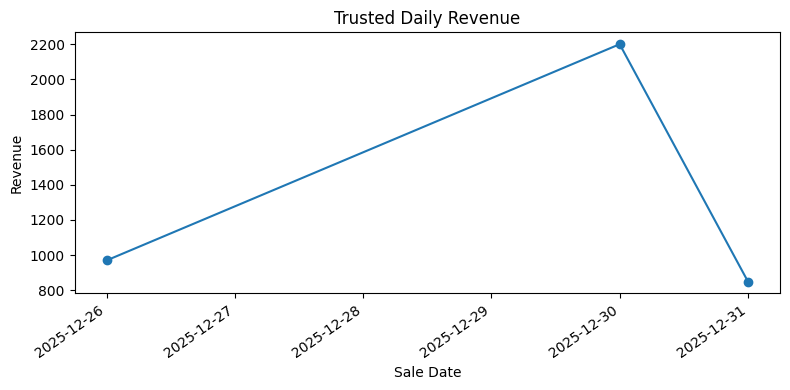

In [24]:
# =========================================================
# Cell 24: Analytics Query 3 - Daily Sales Trend
# =========================================================

daily_sales = run_sql("""
SELECT
    d.full_date,
    SUM(f.final_sale_price) AS daily_revenue
FROM gold.fact_sales f
JOIN gold.dim_date d ON f.date_key = d.date_key
GROUP BY d.full_date
ORDER BY d.full_date;
""", "Daily trusted sales trend")

ax = daily_sales.plot(kind="line", x="full_date", y="daily_revenue", marker="o", legend=False, figsize=(8, 4))
ax.set_title("Trusted Daily Revenue")
ax.set_xlabel("Sale Date")
ax.set_ylabel("Revenue")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


# ✅ Data Quality Tests

A flagship notebook should include automated checks. These tests prove that the expected teaching outcomes are true.


In [25]:
# =========================================================
# Cell 25: Automated Data Quality Assertions
# =========================================================

checks = {
    "Bronze has 10 raw rows": ("SELECT COUNT(*) FROM bronze.sales_raw", 10),
    "After dedup has 9 rows": ("SELECT COUNT(*) FROM silver.step01_dedup", 9),
    "Rejected records count is 5": ("SELECT COUNT(*) FROM silver.rejected_records", 5),
    "Cancelled transactions count is 1": ("SELECT COUNT(*) FROM silver.cancelled_transactions", 1),
    "Trusted clean sales count is 3": ("SELECT COUNT(*) FROM silver.sales_clean", 3),
    "Gold fact sales count is 3": ("SELECT COUNT(*) FROM gold.fact_sales", 3),
}

results = []
for check_name, (sql, expected) in checks.items():
    actual = con.execute(sql).fetchone()[0]
    status = "PASS" if actual == expected else "FAIL"
    results.append({"check": check_name, "expected": expected, "actual": actual, "status": status})
    assert actual == expected, f"{check_name}: expected {expected}, got {actual}"

quality_df = pd.DataFrame(results)
display(quality_df)
print("All data quality checks passed.")


,check,expected,actual,status
0,Bronze has 10 raw rows,10,10,PASS
1,After dedup has 9 rows,9,9,PASS
2,Rejected records count is 5,5,5,PASS
3,Cancelled transactions count is 1,1,1,PASS
4,Trusted clean sales count is 3,3,3,PASS
5,Gold fact sales count is 3,3,3,PASS


All data quality checks passed.


# 🧠 Instructor Discussion Questions

1. Why is row 3 cancelled, but row 4 rejected?
2. Why does row 6 get rejected even though its missing discount was fixed?
3. Why should row 8 disappear before revenue analysis?
4. Why does row 10 fail even though the date format looks valid?
5. What would happen if Gold were built directly from Bronze?
6. Which step would you change if the business decided that missing dates should be imputed instead of rejected?


# Final Takeaway

This 10-row case study shows the full medallion story:

- **Bronze** preserves the landed source
- **Silver** applies data-quality rules step-by-step
- **Rejected records** are separated from **cancelled transactions**
- **Gold** contains only trusted analytics-ready data
- A star schema makes the trusted data easier to analyze

Small datasets can teach big data engineering ideas when every row has a purpose.


In [26]:
# =========================================================
# Optional: Close DuckDB Connection
# =========================================================
# Run this at the very end if you want to release the database file handle.

con.close()
print("DuckDB connection closed.")


DuckDB connection closed.
